In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Cleaned_IT_Incident_Data.csv")

print("Cleaned dataset loaded successfully!")

Cleaned dataset loaded successfully!


In [85]:
df

,incident_id,timestamp,server_id,department,environment,server_type,cpu_usage_pct,memory_usage_pct,disk_usage_pct,network_latency_ms,...,uptime_days,previous_incidents_30d,maintenance_due,anomaly_score,incident_occurred,severity,incident_type,status,resolution_time_minutes,root_cause
0,INC-0001,2025-01-01 07:05:00,SRV-008,Customer Support,Staging,Web Server,23.32,55.73,66.22,103.10,...,1,0,No,0.00,No,No Incident,No Incident,Normal,0.0,No Incident
1,INC-0002,2025-01-01 09:59:00,SRV-010,Customer Support,Production,File Server,82.30,72.72,59.27,138.25,...,141,1,No,5.61,No,No Incident,No Incident,Normal,0.0,No Incident
2,INC-0003,2025-01-01 20:06:00,SRV-043,Operations,Production,API Gateway,74.19,64.79,54.89,165.19,...,25,2,Yes,49.50,No,No Incident,No Incident,Normal,0.0,No Incident
3,INC-0004,2025-01-02 05:33:00,SRV-050,Operations,Development,Database Server,22.94,54.27,42.49,46.62,...,60,1,Yes,6.83,No,No Incident,No Incident,Normal,0.0,No Incident
4,INC-0005,2025-01-02 13:40:00,SRV-024,IT,Production,Application Server,48.15,39.90,79.66,65.56,...,41,0,No,11.10,No,No Incident,No Incident,Normal,0.0,No Incident
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,INC-0996,2025-12-29 21:44:00,SRV-047,IT,Production,Application Server,42.36,44.77,55.41,11.90,...,40,1,No,0.81,No,No Incident,No Incident,Normal,0.0,No Incident
996,INC-0997,2025-12-29 23:47:00,SRV-028,Sales,Development,Application Server,34.11,57.20,60.06,59.07,...,68,0,No,0.00,No,No Incident,No Incident,Normal,0.0,No Incident
997,INC-0998,2025-12-30 12:41:00,SRV-047,Finance,Production,API Gateway,51.83,58.62,64.26,42.70,...,72,3,No,1.26,No,No Incident,No Incident,Normal,0.0,No Incident
998,INC-0999,2025-12-31 10:23:00,SRV-012,Customer Support,Development,Database Server,56.29,30.38,75.21,30.26,...,138,0,No,9.28,No,No Incident,No Incident,Normal,0.0,No Incident


In [86]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Rows: 1000
Columns: 25
Missing values: 0
Duplicates: 0


In [87]:
df.columns

Index(['incident_id', 'timestamp', 'server_id', 'department', 'environment',
       'server_type', 'cpu_usage_pct', 'memory_usage_pct', 'disk_usage_pct',
       'network_latency_ms', 'response_time_ms', 'error_count', 'active_users',
       'packet_loss_pct', 'temperature_c', 'uptime_days',
       'previous_incidents_30d', 'maintenance_due', 'anomaly_score',
       'incident_occurred', 'severity', 'incident_type', 'status',
       'resolution_time_minutes', 'root_cause'],
      dtype='str')

In [88]:
df["incident_occurred"].value_counts()

incident_occurred
No     902
Yes     98
Name: count, dtype: int64

In [89]:
incident_percentage = (
    df["incident_occurred"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(incident_percentage)

incident_occurred
No     90.2
Yes     9.8
Name: proportion, dtype: float64


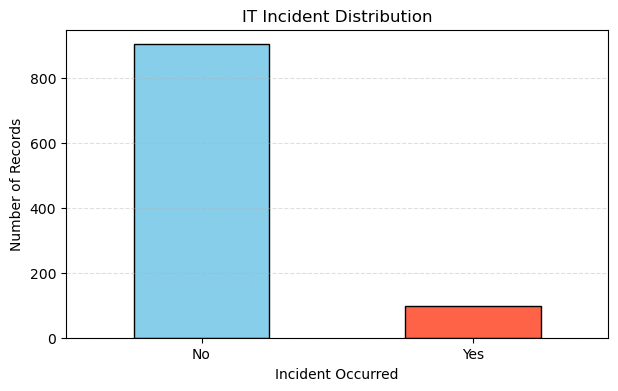

In [90]:
incident_counts = df["incident_occurred"].value_counts()

colors = ["skyblue", "tomato"]

incident_counts.plot(
    kind="bar",
    figsize=(7, 4),
    color=colors,
    edgecolor="black",
    title="IT Incident Distribution"
)

plt.xlabel("Incident Occurred")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

In [91]:
# Count severity levels
severity_order = [
    "No Incident",
    "Low",
    "Medium",
    "High",
    "Critical"
]

severity_counts = (
    df["severity"]
    .value_counts()
    .reindex(severity_order, fill_value=0)
)

print(severity_counts)

severity
No Incident    902
Low             54
Medium           9
High             7
Critical        28
Name: count, dtype: int64


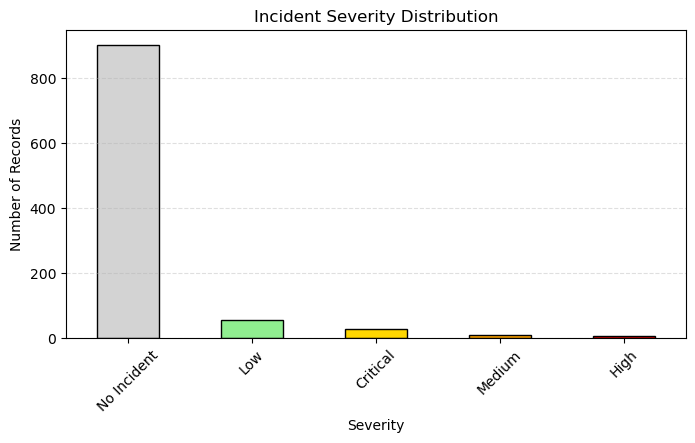

In [92]:
severity_counts = df["severity"].value_counts()

colors = [
    "lightgray",
    "lightgreen",
    "gold",
    "orange",
    "red"
]

severity_counts.plot(
    kind="bar",
    figsize=(8, 4),
    color=colors,
    edgecolor="black",
    title="Incident Severity Distribution"
)

plt.xlabel("Severity")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

In [93]:
department_counts = df["department"].value_counts()

print(department_counts)

department
Operations          211
IT                  209
Sales               183
Finance             162
Customer Support    151
Human Resources      84
Name: count, dtype: int64


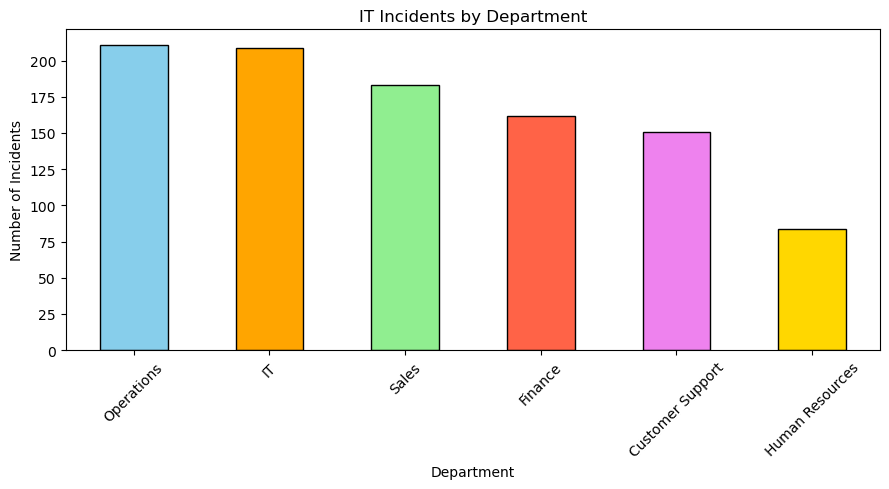

In [94]:
colors = [
    "skyblue",
    "orange",
    "lightgreen",
    "tomato",
    "violet",
    "gold"
]

department_counts.plot(
    kind="bar",
    figsize=(9, 5),
    color=colors,
    edgecolor="black"
)

plt.title("IT Incidents by Department")
plt.xlabel("Department")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [95]:
top_department = department_counts.idxmax()
top_incidents = department_counts.max()

print("Department with most incidents:", top_department)
print("Number of incidents:", top_incidents)

Department with most incidents: Operations
Number of incidents: 211


In [96]:
cpu_average = df.groupby(
    "incident_occurred"
)["cpu_usage_pct"].mean()

print(cpu_average)

incident_occurred
No     49.875133
Yes    77.333265
Name: cpu_usage_pct, dtype: float64


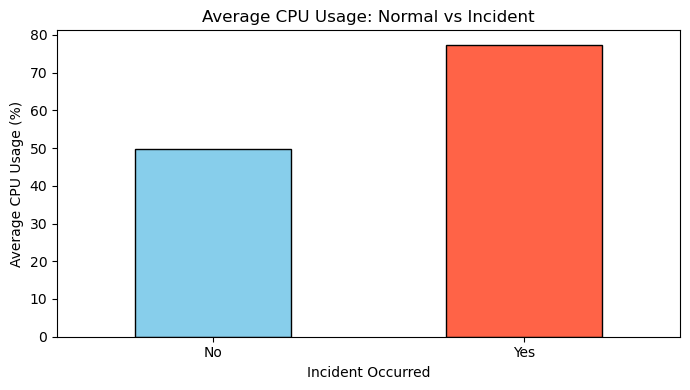

In [97]:
colors = ["skyblue", "tomato"]

cpu_average.plot(
    kind="bar",
    figsize=(7, 4),
    color=colors,
    edgecolor="black"
)

plt.title("Average CPU Usage: Normal vs Incident")
plt.xlabel("Incident Occurred")
plt.ylabel("Average CPU Usage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [98]:
print(
    "Normal average CPU:",
    round(cpu_average["No"], 2),
    "%"
)

print(
    "Incident average CPU:",
    round(cpu_average["Yes"], 2),
    "%"
)

Normal average CPU: 49.88 %
Incident average CPU: 77.33 %


# No = Normal system condition
# Yes = IT problem detected

In [99]:
memory_average = df.groupby(
    "incident_occurred"
)["memory_usage_pct"].mean()

print(memory_average)

incident_occurred
No     52.209823
Yes    68.617143
Name: memory_usage_pct, dtype: float64


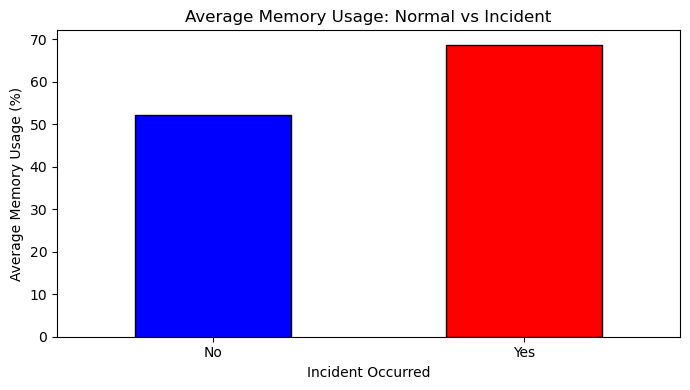

In [100]:
colors = ["blue", "red"]

memory_average.plot(
    kind="bar",
    figsize=(7, 4),
    color=colors,
    edgecolor="black"
)

plt.title("Average Memory Usage: Normal vs Incident")
plt.xlabel("Incident Occurred")
plt.ylabel("Average Memory Usage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [101]:
print(
    "No incident average memory:",
    round(memory_average["No"], 2),
    "%"
)

print(
    "Incident average memory:",
    round(memory_average["Yes"], 2),
    "%"
)

No incident average memory: 52.21 %
Incident average memory: 68.62 %


In [102]:
error_average = df.groupby(
    "incident_occurred"
)["error_count"].mean()

print(error_average)

incident_occurred
No      2.680710
Yes    10.632653
Name: error_count, dtype: float64


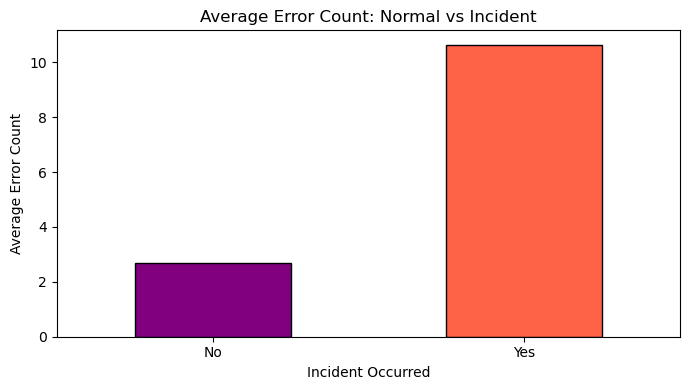

In [103]:
colors = ["purple", "tomato"]

error_average.plot(
    kind="bar",
    figsize=(7, 4),
    color=colors,
    edgecolor="black"
)

plt.title("Average Error Count: Normal vs Incident")
plt.xlabel("Incident Occurred")
plt.ylabel("Average Error Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [104]:
print(
    "No incident average errors:",
    round(error_average["No"], 2)
)

print(
    "Incident average errors:",
    round(error_average["Yes"], 2)
)

No incident average errors: 2.68
Incident average errors: 10.63


In [105]:
response_average = df.groupby(
    "incident_occurred"
)["response_time_ms"].mean()

print(response_average)

incident_occurred
No     328.974723
Yes    979.985408
Name: response_time_ms, dtype: float64


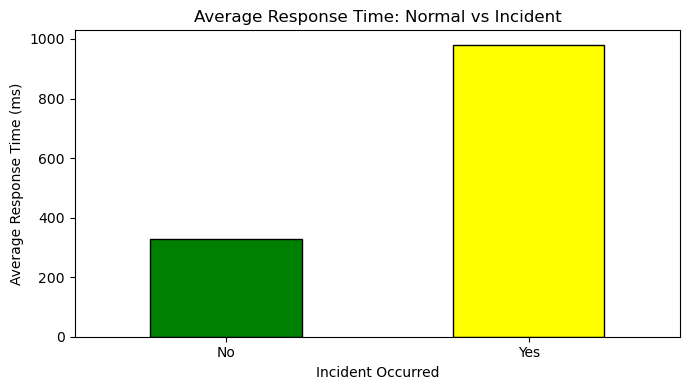

In [106]:
colors = ["green", "yellow"]

response_average.plot(
    kind="bar",
    figsize=(7, 4),
    color=colors,
    edgecolor="black"
)

plt.title("Average Response Time: Normal vs Incident")
plt.xlabel("Incident Occurred")
plt.ylabel("Average Response Time (ms)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [107]:
print(
    "No incident average response time:",
    round(response_average["No"], 2),
    "ms"
)

print(
    "Incident average response time:",
    round(response_average["Yes"], 2),
    "ms"
)

No incident average response time: 328.97 ms
Incident average response time: 979.99 ms


In [108]:
anomaly_average = df.groupby(
    "incident_occurred"
)["anomaly_score"].mean()

print(anomaly_average)


incident_occurred
No      6.989967
Yes    47.437041
Name: anomaly_score, dtype: float64


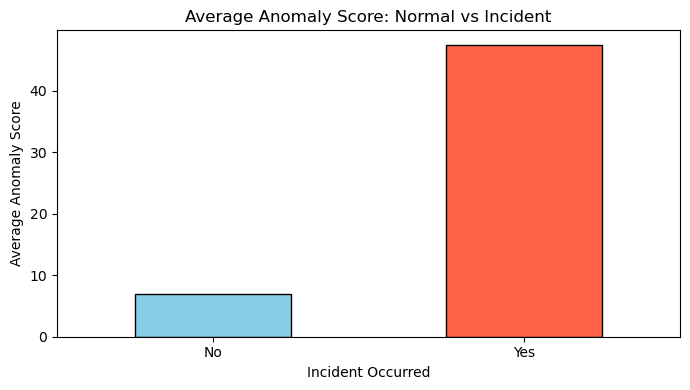

In [109]:
colors = ["skyblue", "tomato"]

anomaly_average.plot(
    kind="bar",
    figsize=(7, 4),
    color=colors,
    edgecolor="black"
)

plt.title("Average Anomaly Score: Normal vs Incident")
plt.xlabel("Incident Occurred")
plt.ylabel("Average Anomaly Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [110]:
print(
    "No incident average anomaly score:",
    round(anomaly_average["No"], 2)
)

print(
    "Incident average anomaly score:",
    round(anomaly_average["Yes"], 2)
)

No incident average anomaly score: 6.99
Incident average anomaly score: 47.44


In [111]:
incident_df = df[df["incident_occurred"] == "Yes"]

In [112]:
environment_counts = incident_df["environment"].value_counts()

print(environment_counts)

environment
Production     68
Staging        19
Development    11
Name: count, dtype: int64


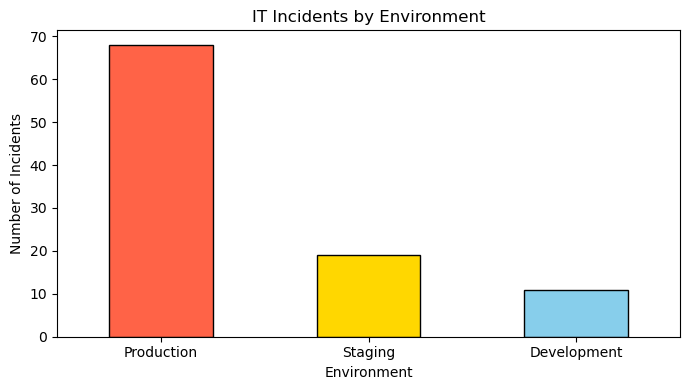

In [113]:
colors = ["tomato", "gold", "skyblue"]

environment_counts.plot(
    kind="bar",
    figsize=(7, 4),
    color=colors,
    edgecolor="black"
)

plt.title("IT Incidents by Environment")
plt.xlabel("Environment")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [114]:
server_type_counts = incident_df["server_type"].value_counts()

print(server_type_counts)

server_type
Web Server            33
Application Server    22
Database Server       20
File Server           16
API Gateway            7
Name: count, dtype: int64


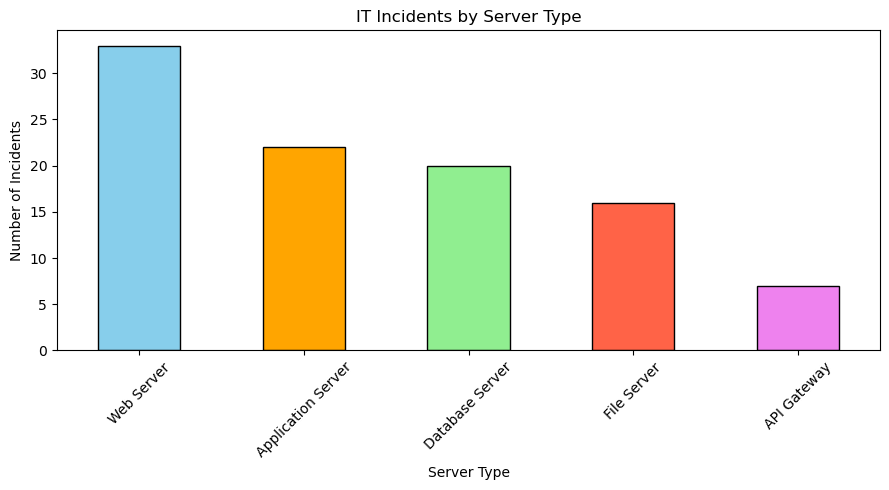

In [115]:
colors = [
    "skyblue",
    "orange",
    "lightgreen",
    "tomato",
    "violet"
]

server_type_counts.plot(
    kind="bar",
    figsize=(9, 5),
    color=colors,
    edgecolor="black"
)

plt.title("IT Incidents by Server Type")
plt.xlabel("Server Type")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [116]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [117]:
df["month_name"] = df["timestamp"].dt.month_name()

In [118]:
incident_df = df[df["incident_occurred"] == "Yes"]

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_incidents = (
    incident_df["month_name"]
    .value_counts()
    .reindex(month_order, fill_value=0)
)

print(monthly_incidents)

month_name
January       5
February      2
March        11
April         8
May           4
June         10
July          9
August       11
September    12
October       8
November     12
December      6
Name: count, dtype: int64


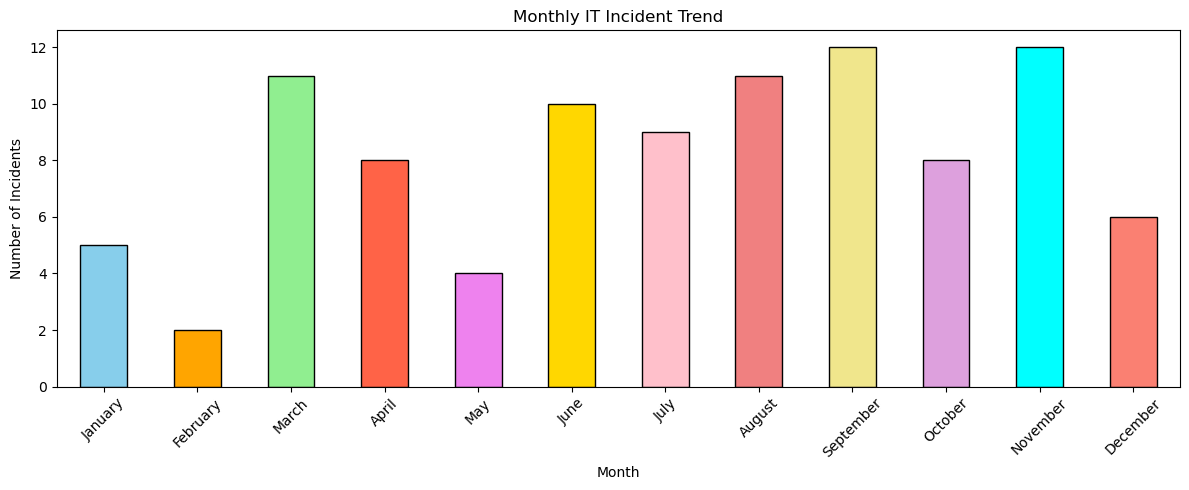

In [119]:
colors = [
    "skyblue", "orange", "lightgreen", "tomato",
    "violet", "gold", "pink", "lightcoral",
    "khaki", "plum", "cyan", "salmon"
]

monthly_incidents.plot(
    kind="bar",
    figsize=(12, 5),
    color=colors,
    edgecolor="black"
)

plt.title("Monthly IT Incident Trend")
plt.xlabel("Month")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [120]:
top_month = monthly_incidents.idxmax()
top_month_count = monthly_incidents.max()

print("Month with most incidents:", top_month)
print("Number of incidents:", top_month_count)

Month with most incidents: September
Number of incidents: 12


In [121]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["hour"] = df["timestamp"].dt.hour

In [122]:
incident_df = df[df["incident_occurred"] == "Yes"]

In [123]:
hourly_incidents = (
    incident_df["hour"]
    .value_counts()
    .sort_index()
)

print(hourly_incidents)

hour
0     5
1     4
2     6
3     4
4     6
5     3
6     7
7     4
8     4
9     3
10    2
11    4
12    3
13    5
14    4
15    2
16    8
17    3
18    2
19    3
20    5
21    4
22    4
23    3
Name: count, dtype: int64


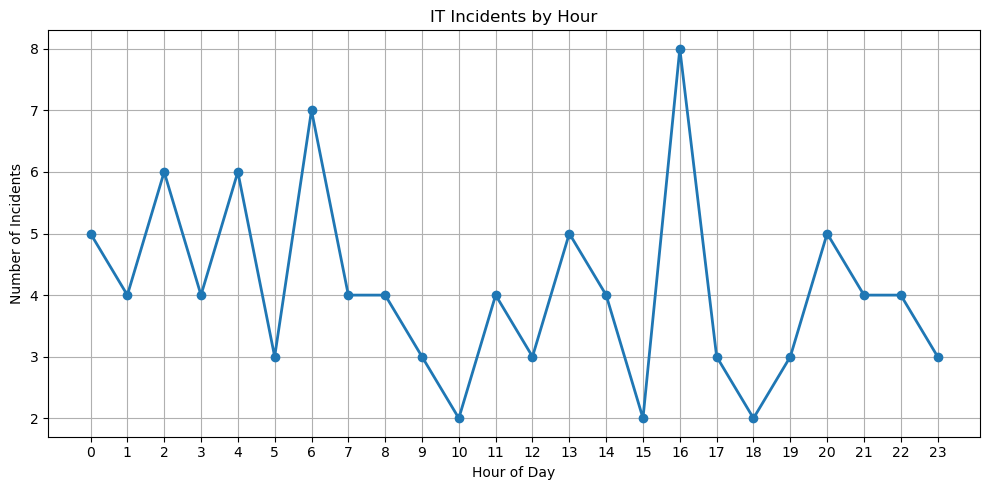

In [124]:
hourly_incidents.plot(
    kind="line",
    figsize=(10, 5),
    marker="o",
    linewidth=2
)

plt.title("IT Incidents by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Incidents")
plt.xticks(range(0, 24))
plt.grid()
plt.tight_layout()
plt.show()

In [125]:
top_hour = hourly_incidents.idxmax()
top_hour_count = hourly_incidents.max()

print("Hour with most incidents:", top_hour)
print("Number of incidents:", top_hour_count)

Hour with most incidents: 16
Number of incidents: 8


In [126]:
incident_df = df[df["incident_occurred"] == "Yes"]

In [127]:
maintenance_counts = incident_df["maintenance_due"].value_counts()

print(maintenance_counts)

maintenance_due
No     71
Yes    27
Name: count, dtype: int64


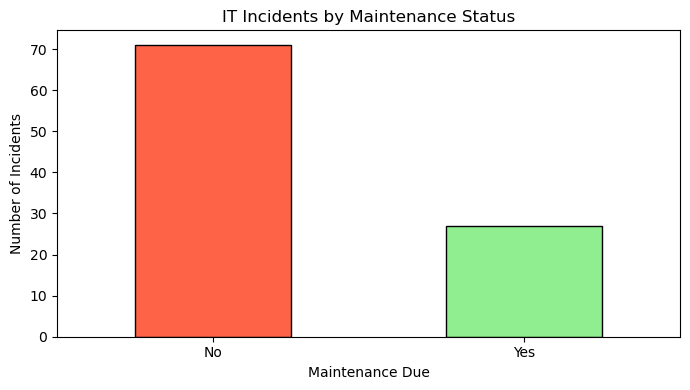

In [128]:
colors = ["tomato", "lightgreen"]

maintenance_counts.plot(
    kind="bar",
    figsize=(7, 4),
    color=colors,
    edgecolor="black"
)

plt.title("IT Incidents by Maintenance Status")
plt.xlabel("Maintenance Due")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [129]:
top_status = maintenance_counts.idxmax()
top_count = maintenance_counts.max()

print("Status with most incidents:", top_status)
print("Number of incidents:", top_count)

Status with most incidents: No
Number of incidents: 71


In [130]:
network_average = df.groupby(
    "incident_occurred"
)["network_latency_ms"].mean()

print(network_average)

incident_occurred
No      51.217439
Yes    141.795000
Name: network_latency_ms, dtype: float64


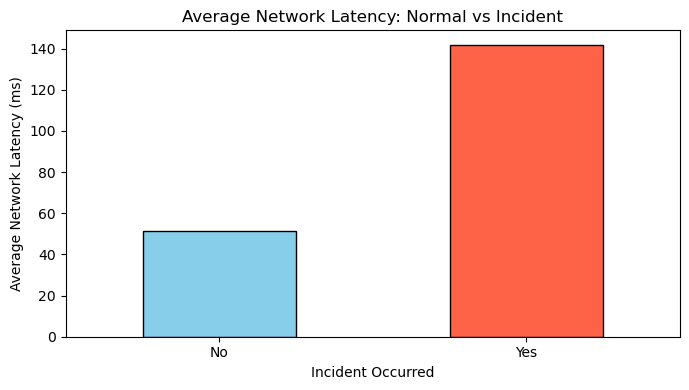

In [131]:
colors = ["skyblue", "tomato"]

network_average.plot(
    kind="bar",
    figsize=(7, 4),
    color=colors,
    edgecolor="black"
)

plt.title("Average Network Latency: Normal vs Incident")
plt.xlabel("Incident Occurred")
plt.ylabel("Average Network Latency (ms)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [132]:
print(
    "No incident network latency:",
    round(network_average["No"], 2),
    "ms"
)

print(
    "Incident network latency:",
    round(network_average["Yes"], 2),
    "ms"
)

No incident network latency: 51.22 ms
Incident network latency: 141.79 ms


In [133]:
disk_average = df.groupby(
    "incident_occurred"
)["disk_usage_pct"].mean()

print(disk_average)

incident_occurred
No     62.282151
Yes    72.840816
Name: disk_usage_pct, dtype: float64


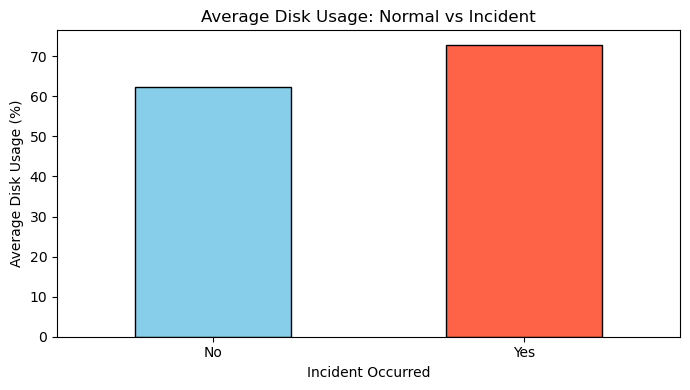

In [134]:
colors = ["skyblue", "tomato"]

disk_average.plot(
    kind="bar",
    figsize=(7, 4),
    color=colors,
    edgecolor="black"
)

plt.title("Average Disk Usage: Normal vs Incident")
plt.xlabel("Incident Occurred")
plt.ylabel("Average Disk Usage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [135]:
print(
    "No incident average disk usage:",
    round(disk_average["No"], 2),
    "%"
)

print(
    "Incident average disk usage:",
    round(disk_average["Yes"], 2),
    "%"
)

No incident average disk usage: 62.28 %
Incident average disk usage: 72.84 %


In [136]:
temperature_average = df.groupby(
    "incident_occurred"
)["temperature_c"].mean()

print(temperature_average)

incident_occurred
No     54.949346
Yes    68.346531
Name: temperature_c, dtype: float64


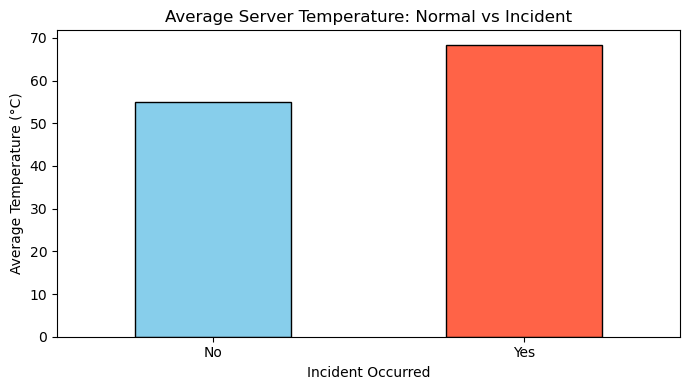

In [137]:
colors = ["skyblue", "tomato"]

temperature_average.plot(
    kind="bar",
    figsize=(7, 4),
    color=colors,
    edgecolor="black"
)

plt.title("Average Server Temperature: Normal vs Incident")
plt.xlabel("Incident Occurred")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [138]:
print(
    "No incident average temperature:",
    round(temperature_average["No"], 2),
    "°C"
)

print(
    "Incident average temperature:",
    round(temperature_average["Yes"], 2),
    "°C"
)

No incident average temperature: 54.95 °C
Incident average temperature: 68.35 °C


In [139]:
packet_loss_average = df.groupby(
    "incident_occurred"
)["packet_loss_pct"].mean()

print(packet_loss_average)

incident_occurred
No     0.970599
Yes    3.344388
Name: packet_loss_pct, dtype: float64


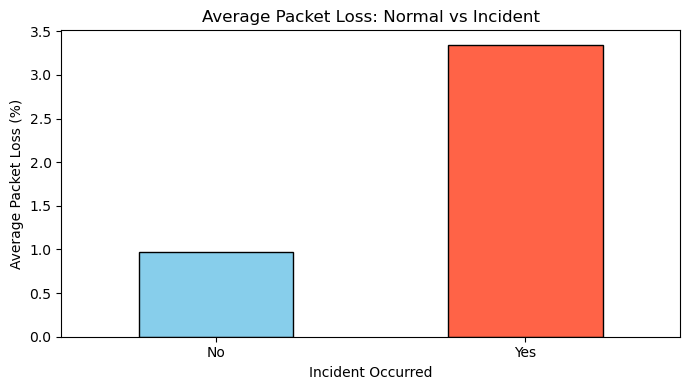

In [140]:
colors = ["skyblue", "tomato"]

packet_loss_average.plot(
    kind="bar",
    figsize=(7, 4),
    color=colors,
    edgecolor="black"
)

plt.title("Average Packet Loss: Normal vs Incident")
plt.xlabel("Incident Occurred")
plt.ylabel("Average Packet Loss (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [141]:
print(
    "No incident average packet loss:",
    round(packet_loss_average["No"], 2),
    "%"
)

print(
    "Incident average packet loss:",
    round(packet_loss_average["Yes"], 2),
    "%"
)

No incident average packet loss: 0.97 %
Incident average packet loss: 3.34 %


In [142]:
previous_incident_average = df.groupby(
    "incident_occurred"
)["previous_incidents_30d"].mean()

print(previous_incident_average)

incident_occurred
No     1.953437
Yes    2.479592
Name: previous_incidents_30d, dtype: float64


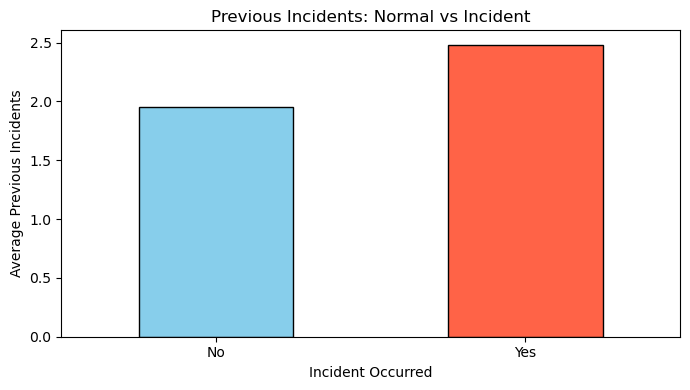

In [143]:
colors = ["skyblue", "tomato"]

previous_incident_average.plot(
    kind="bar",
    figsize=(7, 4),
    color=colors,
    edgecolor="black"
)

plt.title("Previous Incidents: Normal vs Incident")
plt.xlabel("Incident Occurred")
plt.ylabel("Average Previous Incidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [144]:
print(
    "No incident average previous incidents:",
    round(previous_incident_average["No"], 2)
)

print(
    "Incident average previous incidents:",
    round(previous_incident_average["Yes"], 2)
)

No incident average previous incidents: 1.95
Incident average previous incidents: 2.48


In [145]:
df["incident_target"] = df["incident_occurred"].map({
    "No": 0,
    "Yes": 1
})

print(df[["incident_occurred", "incident_target"]].head())

  incident_occurred  incident_target
0                No                0
1                No                0
2                No                0
3                No                0
4                No                0


In [146]:
features = [
    "cpu_usage_pct",
    "memory_usage_pct",
    "disk_usage_pct",
    "network_latency_ms",
    "response_time_ms",
    "error_count",
    "packet_loss_pct",
    "temperature_c",
    "previous_incidents_30d",
    "anomaly_score"
]

In [147]:
incident_correlation = (
    df[features + ["incident_target"]]
    .corr()["incident_target"]
    .drop("incident_target")
    .sort_values()
)

print(incident_correlation)

previous_incidents_30d    0.070836
disk_usage_pct            0.199448
memory_usage_pct          0.368001
temperature_c             0.429388
cpu_usage_pct             0.465653
packet_loss_pct           0.472970
error_count               0.497051
network_latency_ms        0.521456
response_time_ms          0.563571
anomaly_score             0.631733
Name: incident_target, dtype: float64


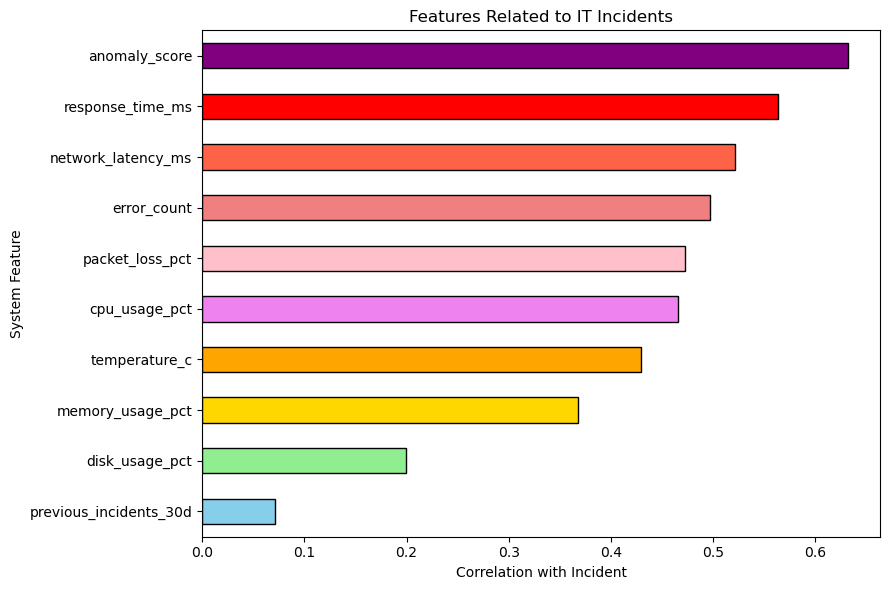

In [148]:
colors = [
    "skyblue",
    "lightgreen",
    "gold",
    "orange",
    "violet",
    "pink",
    "lightcoral",
    "tomato",
    "red",
    "purple"
]

incident_correlation.plot(
    kind="barh",
    figsize=(9, 6),
    color=colors,
    edgecolor="black"
)

plt.title("Features Related to IT Incidents")
plt.xlabel("Correlation with Incident")
plt.ylabel("System Feature")
plt.tight_layout()
plt.show()

In [149]:
heatmap_columns = [
    "cpu_usage_pct",
    "memory_usage_pct",
    "disk_usage_pct",
    "network_latency_ms",
    "response_time_ms",
    "error_count",
    "packet_loss_pct",
    "temperature_c",
    "previous_incidents_30d",
    "anomaly_score",
    "incident_target"
]

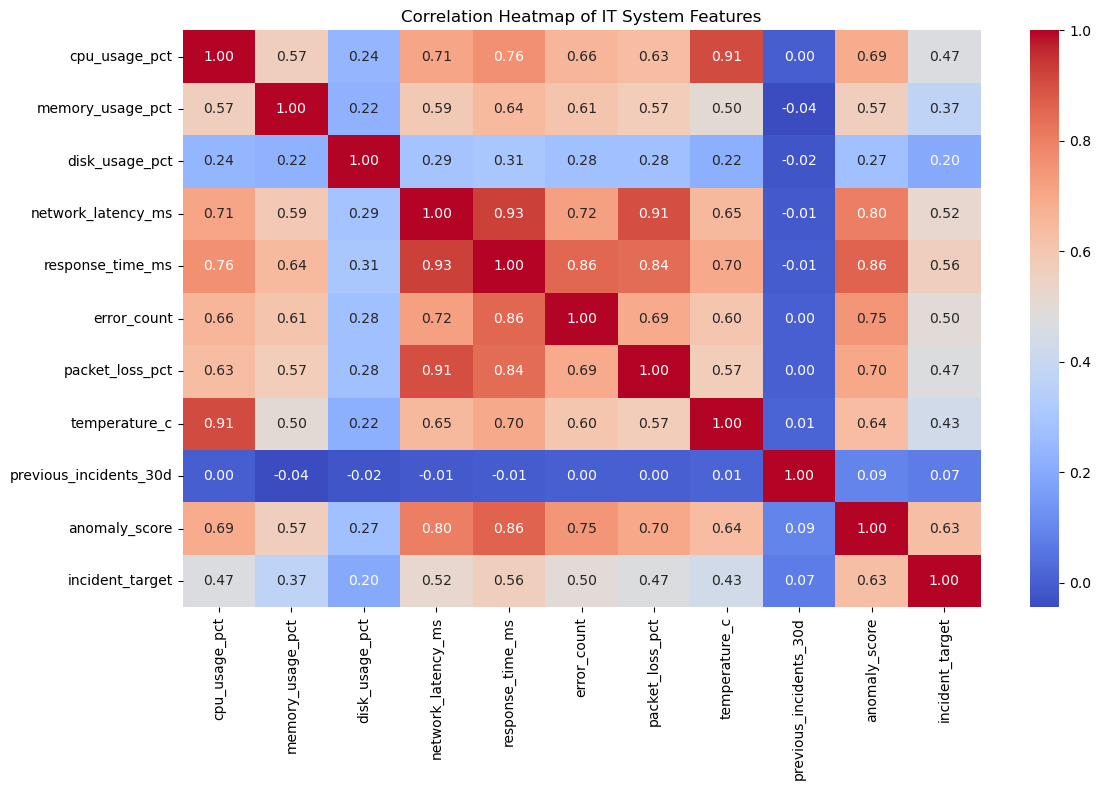

In [150]:
correlation_matrix = df[heatmap_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of IT System Features")
plt.tight_layout()
plt.show()

In [151]:
incident_df = df[df["incident_occurred"] == "Yes"]

In [152]:
server_incidents = incident_df["server_id"].value_counts().head(10)

print(server_incidents)

server_id
SRV-003    6
SRV-006    5
SRV-020    4
SRV-011    4
SRV-049    3
SRV-026    3
SRV-032    3
SRV-012    3
SRV-014    3
SRV-036    3
Name: count, dtype: int64


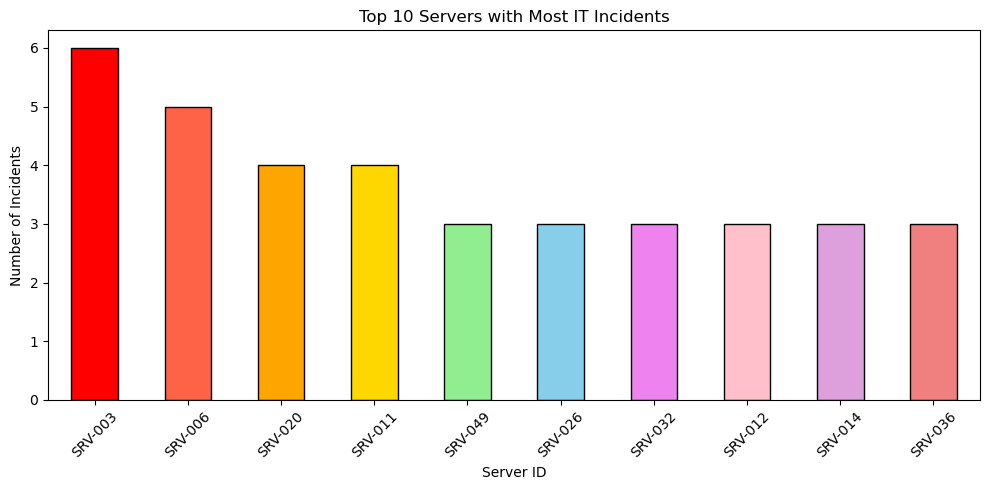

In [153]:
colors = [
    "red",
    "tomato",
    "orange",
    "gold",
    "lightgreen",
    "skyblue",
    "violet",
    "pink",
    "plum",
    "lightcoral"
]

server_incidents.plot(
    kind="bar",
    figsize=(10, 5),
    color=colors,
    edgecolor="black"
)

plt.title("Top 10 Servers with Most IT Incidents")
plt.xlabel("Server ID")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [154]:
top_server = server_incidents.idxmax()
top_server_count = server_incidents.max()

print("Server with most incidents:", top_server)
print("Number of incidents:", top_server_count)

Server with most incidents: SRV-003
Number of incidents: 6


In [155]:
resolved_df = df[
    (df["incident_occurred"] == "Yes") &
    (df["resolution_time_minutes"] > 0)
]

print("Resolved incidents:", len(resolved_df))

Resolved incidents: 93


In [156]:
resolution_average = resolved_df.groupby(
    "severity"
)["resolution_time_minutes"].mean()

print(resolution_average)

severity
Critical    481.074074
High        217.714286
Low          44.725490
Medium       84.625000
Name: resolution_time_minutes, dtype: float64


In [157]:
severity_order = [
    "Low",
    "Medium",
    "High",
    "Critical"
]

resolution_average = resolution_average.reindex(
    severity_order
)

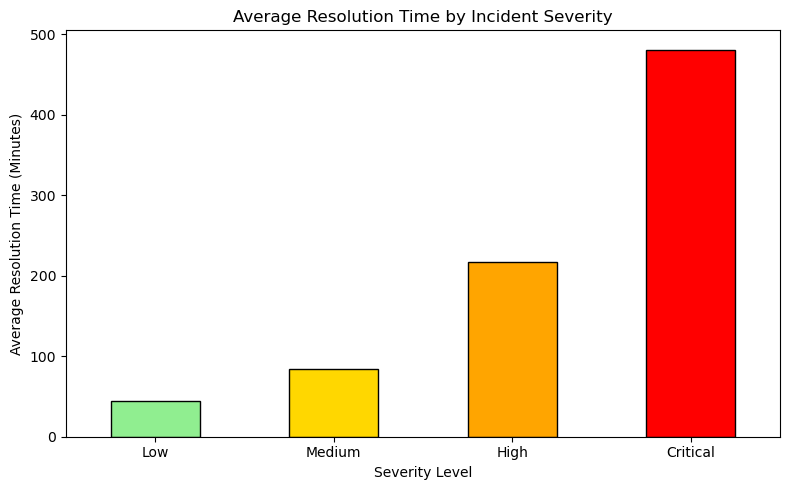

In [167]:
colors = [
    "lightgreen",
    "gold",
    "orange",
    "red"
]

resolution_average.plot(
    kind="bar",
    figsize=(8, 5),
    color=colors,
    edgecolor="black"
)

plt.title("Average Resolution Time by Incident Severity")
plt.xlabel("Severity Level")
plt.ylabel("Average Resolution Time (Minutes)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [159]:
slowest_severity = resolution_average.idxmax()
highest_time = resolution_average.max()

print("Severity taking the longest time:", slowest_severity)
print("Average resolution time:", round(highest_time, 2), "minutes")

Severity taking the longest time: Critical
Average resolution time: 481.07 minutes


In [160]:
resolved_df = df[
    (df["incident_occurred"] == "Yes") &
    (df["resolution_time_minutes"] > 0)
]

print("Resolved incidents:", len(resolved_df))

Resolved incidents: 93


In [161]:
type_resolution = resolved_df.groupby(
    "incident_type"
)["resolution_time_minutes"].mean()

type_resolution = type_resolution.sort_values(
    ascending=False
)

print(type_resolution)

incident_type
CPU Overload            334.346154
Network Latency         197.258065
Application Error        82.625000
Disk Capacity            58.250000
Memory Leak              57.600000
Hardware Overheating     53.000000
Name: resolution_time_minutes, dtype: float64


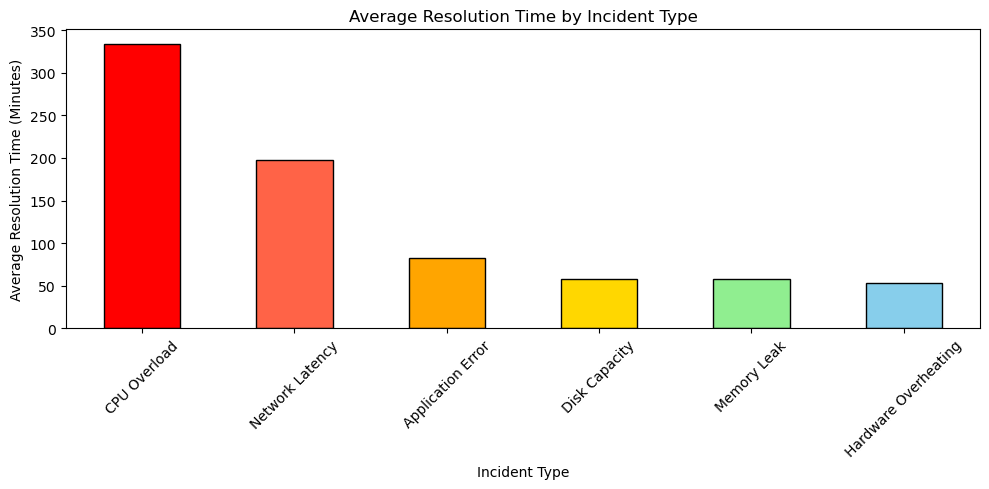

In [162]:
colors = [
    "red",
    "tomato",
    "orange",
    "gold",
    "lightgreen",
    "skyblue",
    "violet"
]

type_resolution.plot(
    kind="bar",
    figsize=(10, 5),
    color=colors,
    edgecolor="black"
)

plt.title("Average Resolution Time by Incident Type")
plt.xlabel("Incident Type")
plt.ylabel("Average Resolution Time (Minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [163]:
slowest_type = type_resolution.idxmax()
slowest_time = type_resolution.max()

print("Incident type taking longest time:", slowest_type)
print("Average resolution time:", round(slowest_time, 2), "minutes")

Incident type taking longest time: CPU Overload
Average resolution time: 334.35 minutes


In [164]:
incident_df = df[df["incident_occurred"] == "Yes"]

status_counts = incident_df["status"].value_counts()

print(status_counts)

status
Resolved      78
Monitoring    15
Open           5
Name: count, dtype: int64


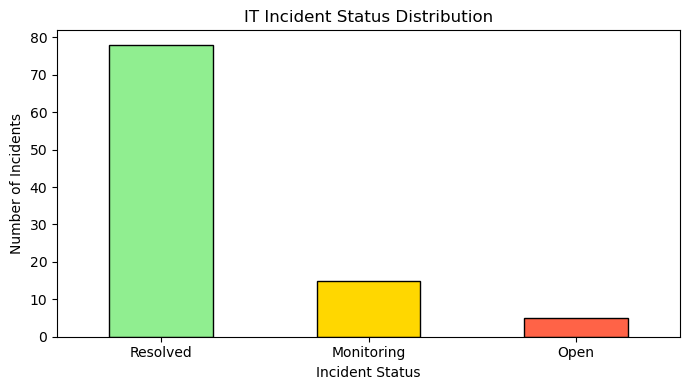

In [165]:
colors = ["lightgreen", "gold", "tomato"]

status_counts.plot(
    kind="bar",
    figsize=(7, 4),
    color=colors,
    edgecolor="black"
)

plt.title("IT Incident Status Distribution")
plt.xlabel("Incident Status")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [166]:
open_incidents = status_counts.get("Open", 0)

print("Open incidents:", open_incidents)

Open incidents: 5


In [168]:
total_department = df["department"].value_counts()

print(total_department)

department
Operations          211
IT                  209
Sales               183
Finance             162
Customer Support    151
Human Resources      84
Name: count, dtype: int64


In [169]:
incident_department = incident_df["department"].value_counts()

incident_department = incident_department.reindex(
    total_department.index,
    fill_value=0
)

print(incident_department)

department
Operations          22
IT                  18
Sales               15
Finance             11
Customer Support    22
Human Resources     10
Name: count, dtype: int64


In [171]:
department_rate = (
    incident_department / total_department * 100
).round(2)

department_rate = department_rate.sort_values(
    ascending=False
)

print(department_rate)

department
Customer Support    14.57
Human Resources     11.90
Operations          10.43
IT                   8.61
Sales                8.20
Finance              6.79
Name: count, dtype: float64


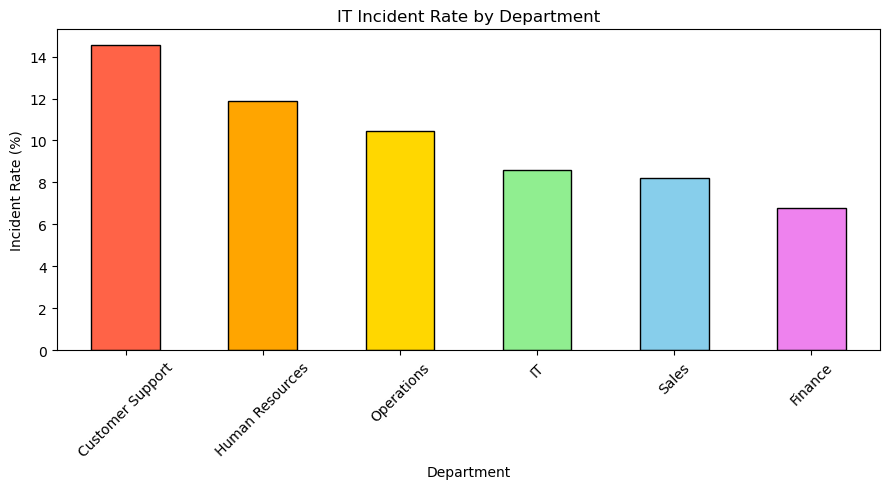

In [172]:
colors = [
    "tomato",
    "orange",
    "gold",
    "lightgreen",
    "skyblue",
    "violet"
]

department_rate.plot(
    kind="bar",
    figsize=(9, 5),
    color=colors,
    edgecolor="black"
)

plt.title("IT Incident Rate by Department")
plt.xlabel("Department")
plt.ylabel("Incident Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [173]:
highest_risk_department = department_rate.idxmax()
highest_rate = department_rate.max()

print("Highest-risk department:", highest_risk_department)
print("Incident rate:", highest_rate, "%")

Highest-risk department: Customer Support
Incident rate: 14.57 %


In [174]:
total_server_type = df["server_type"].value_counts()

print(total_server_type)

server_type
Web Server            259
Application Server    242
Database Server       203
API Gateway           153
File Server           143
Name: count, dtype: int64


In [175]:
incident_server_type = incident_df["server_type"].value_counts()

incident_server_type = incident_server_type.reindex(
    total_server_type.index,
    fill_value=0
)

print(incident_server_type)

server_type
Web Server            33
Application Server    22
Database Server       20
API Gateway            7
File Server           16
Name: count, dtype: int64


In [176]:
server_type_rate = (
    incident_server_type / total_server_type * 100
).round(2)

server_type_rate = server_type_rate.sort_values(
    ascending=False
)

print(server_type_rate)

server_type
Web Server            12.74
File Server           11.19
Database Server        9.85
Application Server     9.09
API Gateway            4.58
Name: count, dtype: float64


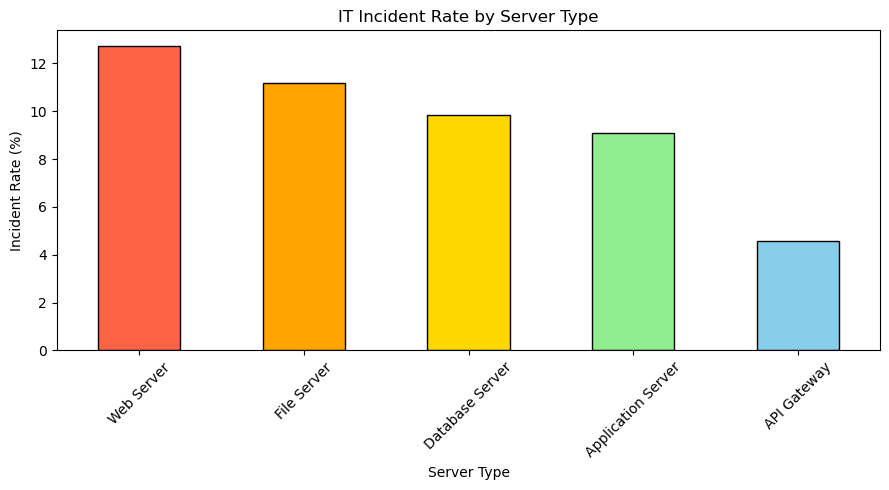

In [177]:
colors = [
    "tomato",
    "orange",
    "gold",
    "lightgreen",
    "skyblue"
]

server_type_rate.plot(
    kind="bar",
    figsize=(9, 5),
    color=colors,
    edgecolor="black"
)

plt.title("IT Incident Rate by Server Type")
plt.xlabel("Server Type")
plt.ylabel("Incident Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [178]:
highest_risk_server_type = server_type_rate.idxmax()
highest_server_rate = server_type_rate.max()

print("Highest-risk server type:", highest_risk_server_type)
print("Incident rate:", highest_server_rate, "%")

Highest-risk server type: Web Server
Incident rate: 12.74 %


In [179]:
print("=" * 55)
print("PHASE 2 — EDA SUMMARY")
print("=" * 55)

print("Total records:", len(df))
print(
    "Total incidents:",
    (df["incident_occurred"] == "Yes").sum()
)
print(
    "Incident rate:",
    round(
        (df["incident_occurred"] == "Yes").mean() * 100,
        2
    ),
    "%"
)

print(
    "Most common incident type:",
    incident_df["incident_type"].mode()[0]
)

print(
    "Department with most incidents:",
    incident_df["department"].mode()[0]
)

print(
    "Server type with most incidents:",
    incident_df["server_type"].mode()[0]
)

print("=" * 55)
print("Phase 2 completed successfully!")

PHASE 2 — EDA SUMMARY
Total records: 1000
Total incidents: 98
Incident rate: 9.8 %
Most common incident type: Network Latency
Department with most incidents: Customer Support
Server type with most incidents: Web Server
Phase 2 completed successfully!
